In [1]:
from sklearn.datasets import make_swiss_roll
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X, y = make_swiss_roll(n_samples=500, noise=0.5, random_state=None, hole=False)
X.shape, y.shape

((500, 3), (500,))

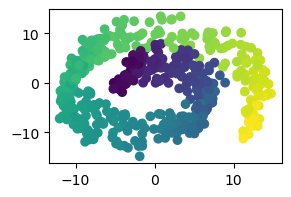

In [3]:
from sklearn.decomposition import PCA
X_pca = PCA(n_components=2).fit_transform(X)
plt.figure(figsize=(3,2))
plt.scatter(X_pca[:, 0], X_pca[:,1], c=y)

In [4]:
import sys
sys.path.append('./')
from limeade import LIMEADE

In [5]:
lm = LIMEADE(data=X, reduced_data=X_pca)
V = lm.fit()
global_attribution = lm.score()

Text(0.5, 1.0, 'Global attributions')

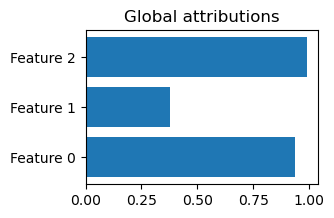

In [25]:
plt.figure(figsize=(3,2))
plt.barh(np.arange(3), global_attribution)
plt.yticks(np.arange(3), [f'Feature {i}' for i in range(3)])
plt.title('Global attributions')

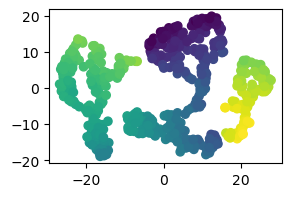

In [7]:
from sklearn.manifold import TSNE
X_tsne = TSNE(n_components=2).fit_transform(X)
plt.figure(figsize=(3,2))
plt.scatter(X_tsne[:, 0], X_tsne[:,1], c=y)

In [14]:
lm = LIMEADE(data=X, reduced_data=X_tsne)
V = lm.fit(level='local')
local_attribution = lm.score(anchor=None)

Text(0.5, 1.0, 'Violin plot of local attributions')

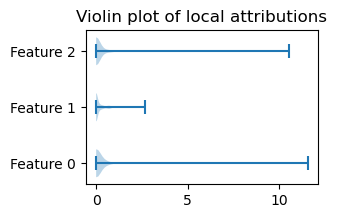

In [31]:
plt.figure(figsize=(3,2))
plt.violinplot([local_attribution[:,j] for j in range(3)], positions=np.arange(3), orientation='horizontal')
plt.yticks(np.arange(3), [f'Feature {i}' for i in range(3)])
plt.title('Violin plot of local attributions')